# Ion Liquid Selection and Reactor-Separator Network Optimization

This script solves a QUBO model for the discrete part of ionic liquid selection and process network optimization problem using simulated annealing, quantum annealing (dwave), and entropy computing (dirac-1). 
The IP formulation of the discrete part of the original problem is documented in "ilrs_discrete_IP.jl" file. In the same file, the JuMP model is converted to a QUBO model using QUBO.jl package, and the resulting QUBO model is exported for use in Python environment.  

The problem involves selecting ionic liquids for a reactor-separator network design, where the goal is to minimize the total cost while satisfying various flow constraints. It is formulated as an integer programming to select ionic liquids and reactor-separator network based on various logical constraints, formulated as linear and/or quadratic constraints. See the "ilrs_discrete_IP.jl" file for the details of the model and Gurobi solver. 

The original MINLP problem is adapted from the following source:

    Iftakher, A., & Hasan, M. M. F. (2024). Exploring quantum optimization for computer-aided Molecular and Process Design. Systems and Control Transactions, 3, 292–299. https://psecommunity.org/LAPSE:2024.1540


In [1]:
import sys
sys.path.append('..')  # Adds the parent directory (il-rxtor-sep-opt) to the path

import pandas as pd
from ilrs_common import *
from ilrs_plotting import *


In [10]:
import os

# Set the D-Wave API token
os.environ["DWAVE_API_TOKEN"] = "your-api-token"

# DATA COLLECTION 
## Import QUBO model and solve using different methods 

In [2]:
# Import Q matrix and scalars from the Julia export (QUBO model)
Q_filepath = "./julia_exports/Q_matrix_1.csv"
L_filepath = "./julia_exports/L_vector_1.csv"
scalars_filepath = "./julia_exports/scalars_1.csv"

Q, beta = import_from_julia(scalars_filepath, Q_filepath, L_filepath)

In [ ]:
# ================ DWave / QA ==========================
# Solve the QUBO model using Dwave quantum annealer (Advantage 2 system)
# Execution time includes embedding time + solving time 
DWaveSamples_zephyr, tts_qa_zephyr = solve_qa_dwave(Q, beta, save=True, topology="zephyr")


Execution time (QAnn):  0.21451497077941895
System name:  Advantage2_system1.8
{'timing': {'qpu_sampling_time': 129420.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 48.85, 'qpu_access_time': 164009.6, 'qpu_access_overhead_time': 8187.4, 'qpu_programming_time': 34589.6, 'qpu_delay_time_per_sample': 60.57, 'total_post_processing_time': 18.0, 'post_processing_overhead_time': 18.0}, 'problem_id': 'a2902231-236d-40f7-a5ef-853228d3ad8e', 'embedding_context': {'embedding': {6: (2605,), 5: (385,), 7: (2677, 457), 8: (396,), 9: (840, 841), 0: (2428,), 10: (828, 2631), 11: (2607, 684), 12: (720, 2535), 13: (672, 2583), 1: (2451,), 14: (708,), 15: (660, 2547), 16: (744, 2571), 17: (745, 2667), 2: (601,), 18: (2643,), 3: (625,), 19: (588, 2523), 4: (577,), 20: (2702,), 21: (2714, 2715), 22: (2654,), 23: (2595,), 24: (649, 2678), 25: (612,), 26: (804, 2524), 27: (852,), 28: (696,), 29: (2559,), 30: (697,), 31: (2679,), 32: (2619, 721), 33: (732,), 34: (2499,), 35: (756,), 36

In [ ]:
# ================ DWave neal / SA ==========================
simAnnSamples, t_simAnn = solve_sim_annealing(Q, beta, save=True)

# ================ DWave / QA ==========================
# Solve the QUBO model using Dwave quantum annealer 
# Execution time includes embedding time + solving time 
DWaveSamples, tts_qa = solve_qa_dwave(Q, beta, save=True)

# ================ QCI dirac-1 / EQC ==========================
# Solve the QUBO model using QCI dirac-1 / EQC 
file_name = "il-rs_mip_decomp.json"
qci_result_df, t_qci = solve_eqc_qci(Q, beta, file_name, num_sample=100)

# If jobinfo is needed, use:
# qci_result_df, t_qci, job_body, job_response = solve_eqc_qci(Q, beta, file_name, num_sample=100, jobinfo=True)

# ========== Data Processing ==========
# Use a function to extract energy and probability data only and convert to dataframe
dwave_df = sampleset_to_df(DWaveSamples)
simAnn_df = sampleset_to_df(simAnnSamples)

df_names = [ 'DWave_QA','SimAnnealing', 'QCI_EQC']
df_list = [dwave_df, simAnn_df, qci_result_df]

Execution time (simAnn):  0.359607458114624


## DATA ANALYSIS 

These results may be collected from DATA COLLECTION section or imported from saved files. 

In [20]:
# ========== Get saved results from JSON files for data analysis ==========
import_dir = './result_raw'

# Simulated annealing results
sa_path = os.path.join(import_dir, 'SA_results_20251121_163831.json')
simAnn_df, t_simAnn = import_sampleset(sa_path)

(dwave_df, dwave_qa_tts_total), dwave_qa_tts_qc = import_sampleset(qa_path, qa=True)
# dwave_qa_tts_qc is quantum time, dwave_qa_tts_total is total execution time

# QCI results
qci_path = os.path.join(import_dir, 'QCI_EQC_results.json')
qci_result_df, t_qci = import_sampleset(qci_path)
# ========== Additional QA results from D-Wave Advantage 2 system ==========

# DWave QA results (Advantage 2)
qa_adv2_path = os.path.join(import_dir, 'Dwave_QA_results_20251120_164900.json')
(dwave_df_adv2, dwave_qa_tts_total_adv2), dwave_qa_tts_qc_adv2 = import_sampleset(qa_adv2_path, qa=True)
# dwave_qa_tts_qc_adv2 is quantum time, dwave_qa_tts_total_adv2 is total execution time


In [21]:
# ========== Calculate time-to-solution (tts) ==========
feas_ub = 57        # upper bound for feasible solution, taken from Gurobi result
opt_ub = 19.1       # upper bound for optimal solution, taken from Gurobi result

# Calculate the time to solution for the feasible solutions (tts_f) and optimal solutions (tts_opt)
sa_tts_f = calculate_tts(simAnn_df, t_simAnn, feas_ub)
sa_tts_opt = calculate_tts(simAnn_df, t_simAnn, opt_ub)
qci_tts_f = calculate_tts(qci_result_df, t_qci, feas_ub)
qci_tts_opt = calculate_tts(qci_result_df, t_qci, opt_ub)
dwave_total_tts_f = calculate_tts(dwave_df, dwave_qa_tts_total, feas_ub)
dwave_total_tts_opt = calculate_tts(dwave_df, dwave_qa_tts_total, opt_ub)
dwave_qc_tts_f = calculate_tts(dwave_df, dwave_qa_tts_qc, feas_ub)
dwave_qc_tts_opt = calculate_tts(dwave_df, dwave_qa_tts_qc, opt_ub)

# ========== Additional QA results from D-Wave Advantage 2 system ==========
dwave_total_tts_f_adv2 = calculate_tts(dwave_df_adv2, dwave_qa_tts_total_adv2, feas_ub)
dwave_total_tts_opt_adv2 = calculate_tts(dwave_df_adv2, dwave_qa_tts_total_adv2, opt_ub)
dwave_qc_tts_f_adv2 = calculate_tts(dwave_df_adv2, dwave_qa_tts_qc_adv2, feas_ub)
dwave_qc_tts_opt_adv2 = calculate_tts(dwave_df_adv2, dwave_qa_tts_qc_adv2, opt_ub)

tts_feas = {
    'SA': sa_tts_f, 
    'QA-DWAVE_qpu': dwave_qc_tts_f, 
    'QA-DWAVE_total': dwave_total_tts_f, 
    'QA-DWAVE2_qpu': dwave_qc_tts_f_adv2, 
    'QA-DWAVE2_total': dwave_total_tts_f_adv2, 
    'EQC-QCI_qpu': qci_tts_f
    }

tts_opt = {
    'SA': sa_tts_opt, 
    'QA-DWAVE_qpu': dwave_qc_tts_opt, 
    'QA-DWAVE_total': dwave_total_tts_opt, 
    'QA-DWAVE2_qpu': dwave_qc_tts_opt_adv2, 
    'QA-DWAVE2_total': dwave_total_tts_opt_adv2, 
    'EQC-QCI_qpu': qci_tts_opt
    }
    
# Format each value to 1 decimal place
formatted_tts_feas = {k: f"{v:.2f}" for k, v in tts_feas.items()}
formatted_tts_opt = {k: f"{v:.2f}" for k, v in tts_opt.items()}

df_tts = pd.DataFrame({
    'TTS_feas': formatted_tts_feas,
    'TTS_opt': formatted_tts_opt
})
print(df_tts)

Probability of solution <= 57 : 0.942
Time to solution <= 57 : 0.581619923858315
Probability of solution <= 19.1 : 0.007
Time to solution <= 19.1 : 235.75008162426838
Probability of solution <= 57 : 1.0
Time to solution <= 57 : 37.0
Probability of solution <= 19.1 : 0.13
Time to solution <= 19.1 : 1223.529853779226
Probability of solution <= 57 : 0.509
Time to solution <= 57 : 10.287397703071216
Probability of solution <= 19.1 : 0.001
Time to solution <= 19.1 : 7313.881322444823
Probability of solution <= 57 : 0.509
Time to solution <= 57 : 0.8727373502248015
Probability of solution <= 19.1 : 0.001
Time to solution <= 19.1 : 620.4773636099966
Probability of solution <= 57 : 0.939
Time to solution <= 57 : 0.3532069477993978
Probability of solution <= 19.1 : 0.004
Time to solution <= 19.1 : 246.47521804352294
Probability of solution <= 57 : 0.939
Time to solution <= 57 : 0.27004795989445224
Probability of solution <= 19.1 : 0.004
Time to solution <= 19.1 : 188.44513170504268
            

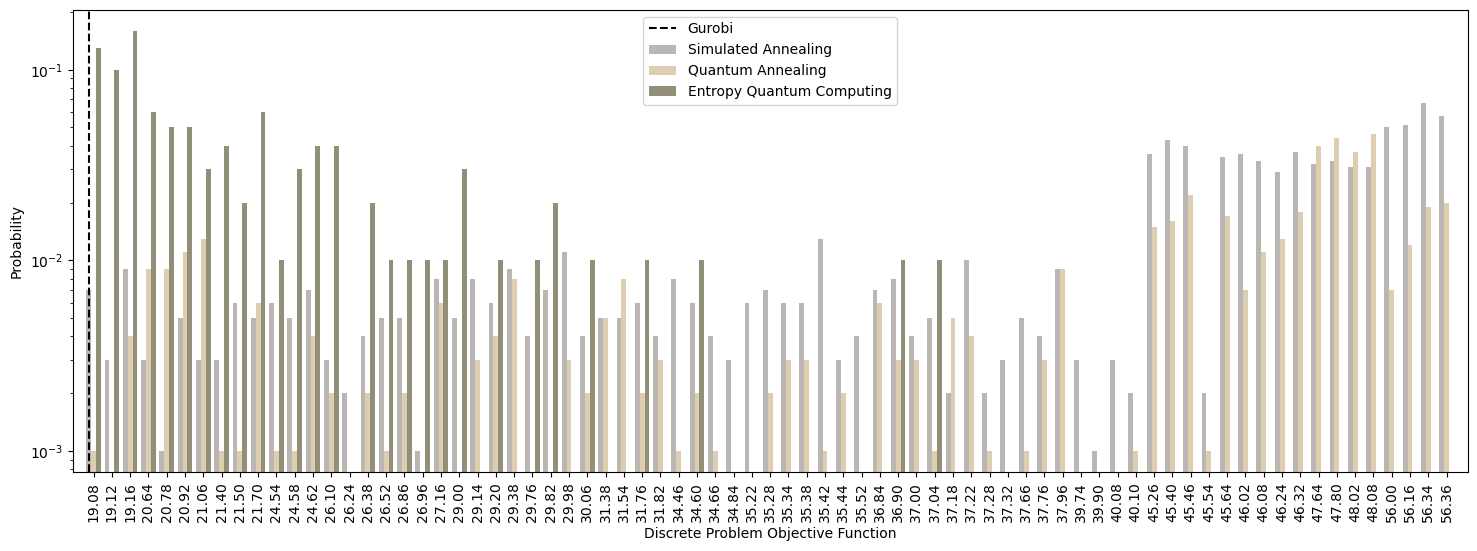

In [23]:
# ========== Plot the results of the optimization ==========
# # combine the probability values that have energy values (infeasible solutions) that are > feas_ub to one value
# simAnn_df_red = sum_infeas_soln(simAnn_df, feas_ub)
# dwave_df_red = sum_infeas_soln(dwave_df, feas_ub)

# Add the Gurobi results to the graph 
gurobi_result = simAnn_df.index[0]

# Plot only feasible solutions
dwave_df_feas = dwave_df[dwave_df.index < feas_ub] 
simAnn_df_feas = simAnn_df[simAnn_df.index < feas_ub]

# Plot the results of the optimization
df_list_feas = [simAnn_df_feas, dwave_df_feas, qci_result_df]  
df_names = ['Simulated Annealing', 'Quantum Annealing', 'Entropy Quantum Computing'] 
df_colors = [ '#9d9795', '#cfb991', '#646040'] 

plot_multibar_graph_discrete(df_list_feas, df_names, df_colors, feas_ub, vertical_line=gurobi_result)

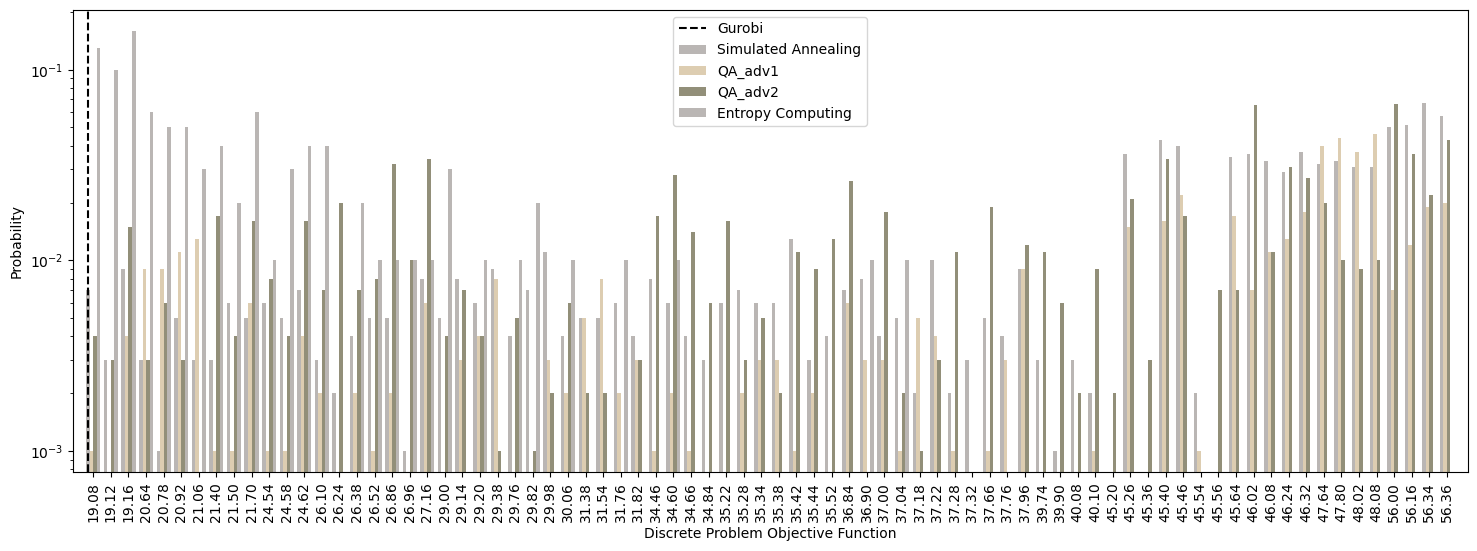

In [24]:
# Plot the results of the optimization
df_names_2 = ['Simulated Annealing', 'QA_adv1', 'QA_adv2', 'Entropy Computing'] 
df_colors_2 = [ '#9d9795', '#cfb991', '#646040', '#9d9795'] 

# Plot only feasible solutions
dwave_df_adv2_feas = dwave_df_adv2[dwave_df_adv2.index < feas_ub]

# Plot the results of the optimization
df_list_feas_2 = [simAnn_df_feas, dwave_df_feas, dwave_df_adv2_feas, qci_result_df]  

plot_multibar_graph_discrete(df_list_feas_2, df_names_2, df_colors_2, feas_ub, vertical_line=gurobi_result)